In [ ]:
from torch import nn
import torch
from torch.utils.data import Subset, Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import os
import torch.optim as optim

In [ ]:
import os
import random
import shutil

src_dir = "./data/celeba/img_align_celeba/img_align_celeba"
dst_dir = "./data/celeba_subset"
os.makedirs(dst_dir, exist_ok=True)

random.seed(42)
all_files = sorted(os.listdir(src_dir))
selected = random.sample(all_files, min(15000, len(all_files)))

for f in selected:
    shutil.copy(os.path.join(src_dir, f), os.path.join(dst_dir, f))

print(f"Скопировано {len(selected)} файлов в {dst_dir}")

In [3]:
class FaceDataset(Dataset):
    def __init__(self, root_dir, img_size=64, train=True):
        self.root_dir = root_dir
        self.files = sorted(os.listdir(root_dir))
        self.train = train

        if self.train:
            self.transform = transforms.Compose([
                transforms.CenterCrop(178),
                transforms.Resize((img_size, img_size)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(
                    brightness=0.1,
                    contrast=0.1,
                    saturation=0.1
                ),
                transforms.RandomRotation(degrees=5),
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            ])

        else:
            self.transform = transforms.Compose([
                transforms.CenterCrop(178),
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            ])
    
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.root_dir, self.files[idx])
        image = Image.open(path).convert("RGB")
        return self.transform(image)



In [4]:
dataset_path = 'data/celeba_subset'
train_dataset = FaceDataset(dataset_path, img_size=64, train=True)
val_dataset = FaceDataset(dataset_path, img_size=64, train=False)

val_len = int(len(train_dataset) * 0.1)
train_len = len(train_dataset) - val_len

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(range(len(train_dataset)), [train_len, val_len], generator=generator)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

len(train_subset), len(val_subset)


(13500, 1500)

In [5]:

class MultiheadSelfAttentionBlock(nn.Module):
    def __init__(self, embedding_dim=768,
    num_heads=12, attn_dropout=0):
        super().__init__()
        self.layer_norm = nn.LayerNorm(
            normalized_shape=embedding_dim) 
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multihead_attn(
            query=x, key=x, value=x, need_weights=False
        )
        return attn_output


class MLPBlock(nn.Module):
    def __init__(self, embedding_dim=128,
    mlp_size=512,
    mlp_dropout=0.1):
        super().__init__()
        self.layer_norm = nn.LayerNorm(
            normalized_shape=embedding_dim)
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
            out_features=mlp_size),
            nn.GELU(),
            nn.Dropout(p=mlp_dropout),
            nn.Linear(in_features=mlp_size,
            out_features=embedding_dim),
            nn.Dropout(p=mlp_dropout)
        )

    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embedding_dim=128,
    num_heads=4, mlp_size=512, mlp_dropout=0.1, attn_dropout=0):
        super().__init__()
        self.msa_block = MultiheadSelfAttentionBlock(
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            attn_dropout=attn_dropout
        )
        self.mlp_block = MLPBlock(
            embedding_dim=embedding_dim,
            mlp_size=mlp_size,
            mlp_dropout=mlp_dropout)

    def forward(self, x):
        x = self.msa_block(x) + x
        x = self.mlp_block(x) + x
        return x

class TransformerDecoderBlock(nn.Module):
    def __init__(self, embedding_dim=128,
    num_heads=4, mlp_size=512, mlp_dropout=0.1, attn_dropout=0):
        super().__init__()
        self.self_attn = MultiheadSelfAttentionBlock(
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            attn_dropout=attn_dropout
        )
        self.cross_attn_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True
        )

        self.mlp = MLPBlock(
            embedding_dim=embedding_dim,
            mlp_size=mlp_size,
            mlp_dropout=mlp_dropout)

    def forward(self, x, memory):
        x = self.self_attn(x) + x
        x_norm = self.cross_attn_norm(x)
        x = self.cross_attn(query=x_norm, key=memory, value=memory, need_weights=False)[0] + x
        x = self.mlp(x) + x
        return x

class TransfomerDecoder(nn.Module):
    def __init__(self,
                 num_layers=2,
                 embedding_dim=128,
                 num_heads=4,
                 mlp_size=512,
                 attn_dropout=0.1,
                 mlp_dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerDecoderBlock(
                embedding_dim=embedding_dim,
                num_heads=num_heads,
                mlp_size=mlp_size,
                attn_dropout=attn_dropout,
                mlp_dropout=mlp_dropout
            ) for _ in range(num_layers)
        ])

    def forward(self, x, memory):
        for layer in self.layers:
            x = layer(x, memory)
        return x


class ResnetVitEncoder(torch.nn.Module):
    def __init__(self,
    num_patches=4*4,
    latent_dim=128,
    num_transformer_layers=2,
    embedding_dim=128,
    mlp_size=512,
    num_heads=4,
    attn_dropout=0,
    mlp_dropout=0.1,
    embedding_dropout=0.1):
        super().__init__()

        resnet = models.resnet18(weights='DEFAULT')
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        self.backbone_blocks = nn.ModuleList([self.stem, self.layer1, self.layer2, self.layer3])
        for block in self.backbone_blocks:
            for p in block.parameters():
                p.requires_grad = False
        backbone_channels = 256

        self.projection = nn.Linear(backbone_channels, embedding_dim)
        self.class_embedding = torch.nn.Parameter(data=torch.rand(1, 1, embedding_dim), requires_grad=True)
        self.position_embedding = torch.nn.Parameter(data=torch.rand(1, num_patches + 1, embedding_dim), requires_grad=True)
        self.embedding_dropout = torch.nn.Dropout(p=embedding_dropout)
        self.transformer_encoder = torch.nn.Sequential(*[TransformerEncoderBlock(
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            mlp_size=mlp_size,
            mlp_dropout=mlp_dropout
        ) for _ in range(num_transformer_layers)])

        self.norm = nn.LayerNorm(embedding_dim)
        self.fc_mu = nn.Linear(embedding_dim, latent_dim)
        self.fc_logvar = nn.Linear(embedding_dim, latent_dim)


    def unfreeze_block(self, block_idx):
        idx_from_end = len(self.backbone_blocks) - 1 - block_idx
        for p in self.backbone_blocks[idx_from_end].parameters():
            p.requires_grad = True
            

    def forward(self, x):
        b = x.shape[0]
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.flatten(2)
        x = x.permute(0, 2, 1)
        x = self.projection(x)
        cls = self.class_embedding.expand(b, -1, -1)
        tokens = torch.cat((cls, x), dim=1) + self.position_embedding
        tokens = self.embedding_dropout(tokens)
        tokens = self.transformer_encoder(tokens)
        cls_out = self.norm(tokens[:, 0])
        return self.fc_mu(cls_out), self.fc_logvar(cls_out)




In [6]:



class DecoderGenerator(nn.Module):
    def __init__(self,
    latent_dim=128,
    num_transformer_layers=2,
    num_queries=64,
    embedding_dim=128,
    mlp_size=512,
    num_heads=4,
    out_channels=3,
    img_size=64,
    attn_dropout=0,
    mlp_dropout=0.1,
    embedding_dropout=0.1):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.grid_size = int(num_queries ** 0.5)
        assert self.grid_size ** 2 == num_queries, 'из num_queries должен извлекаться целый корень'

        self.latent_to_grid = nn.Sequential(
            nn.Linear(latent_dim, embedding_dim * self.grid_size * self.grid_size),
            nn.ReLU(inplace=True)
        )

        upsample_steps = int(torch.log2(torch.tensor(img_size / self.grid_size)).item())
        layers = []
        in_ch = embedding_dim
        for _ in range(upsample_steps):
            out_ch = max(in_ch // 2, 32)
            layers += [
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            ]
            in_ch = out_ch
        layers += [nn.Conv2d(in_ch, out_channels, kernel_size=3, padding=1), nn.Tanh()]
        self.upsample = nn.Sequential(*layers)


    def forward(self, x):
        b = x.shape[0]
        grid = self.latent_to_grid(x).reshape(b, self.embedding_dim, self.grid_size, self.grid_size)
        image = self.upsample(grid)
        return image





        


In [7]:
from torch.nn.utils import spectral_norm

class Discriminator(nn.Module):
    def __init__(self, in_channels=3, base_channels=64, img_size=64):
        super().__init__()
        num_downsamples = int(torch.log2(torch.tensor(img_size / 4)).item())

        layers = []
        ch = base_channels
        layers += [spectral_norm(nn.Conv2d(in_channels, ch, 4, 2, 1)), nn.LeakyReLU(0.2, inplace=True)]
        for _ in range(num_downsamples - 1):
            out_ch = ch * 2
            layers += [
                spectral_norm(nn.Conv2d(ch, out_ch, 4, 2, 1)),
                nn.LeakyReLU(0.2, inplace=True)
            ]
            ch = out_ch

        self.feature_layers = nn.ModuleList(layers)
        self.final = nn.Sequential(
            spectral_norm(nn.Conv2d(ch, 1, 4, 1, 0)),
            # nn.Sigmoid()
        )

    
    def forward(self, x, return_features=False, feature_layer_idx=None):
        features = None
        target_idx = feature_layer_idx if feature_layer_idx is not None else len(self.feature_layers) // 2
        for i, layer in enumerate(self.feature_layers):
            x = layer(x)
            if i == target_idx:
                features = x

        logit = self.final(x)
        logit = logit.view(logit.size(0), -1).mean(dim=1)
        if return_features:
            return logit, features
        return logit
   

In [8]:
bce = nn.BCEWithLogitsLoss()

# разница между распределением энкодера и нормальным распределением
def kl_divergence(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

# организация латентного пространства для обратного рспространения градиентов
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

# ошибки определения реальности и фейка дискриминатором
def discriminator_loss(d_real_logits, d_recon_logits, d_prior_logits, smooth=0.9):
    real_labels = torch.full_like(d_real_logits, smooth)
    fake_labels = torch.zeros_like(d_recon_logits)

    loss_real = bce(d_real_logits, real_labels)
    loss_fake = (bce(d_recon_logits, fake_labels) + bce(d_prior_logits, fake_labels)) / 2 
    return loss_real + loss_fake

# вознаграждается когда обманул дискриминатор
def generator_adversarial_loss(d_recon_logits, d_prior_logits):
    target = torch.ones_like(d_recon_logits)
    return bce(d_recon_logits, target) + bce(d_prior_logits, target)


def add_instance_noise(x, epoch, max_epochs, sigma_start=0.03):
    sigma = max(sigma_start * (1 - epoch / max_epochs), 0.0)
    if sigma == 0:
        return x
    return x + torch.randn_like(x) * sigma
    

@torch.no_grad()
def validate(encoder, generator, discriminator, val_loader, device, latent_dim=128):
    encoder.eval()
    generator.eval()
    discriminator.eval()
    n_batches = len(val_loader)
    total_kl, total_llike, total_d_loss, total_adv_loss, total_d_acc, total_pixel = 0, 0, 0, 0, 0, 0

    for x in val_loader:
        x = x.to(device)
        b = x.shape[0]

        mu, logvar = encoder(x)
        z = reparameterize(mu, logvar)
        x_recon = generator(z)

        z_prior = torch.randn(b, latent_dim, device=device)
        x_prior = generator(z_prior)

        kl_loss = kl_divergence(mu, logvar)

        d_real, feat_real = discriminator(x, return_features=True)
        d_recon, feat_recon = discriminator(x_recon, return_features=True)
        d_prior = discriminator(x_prior)

        llike_loss = nn.functional.mse_loss(feat_recon, feat_real)

        d_loss = discriminator_loss(d_real, d_recon, d_prior)

        adv_loss = generator_adversarial_loss(d_recon, d_prior)

        d_real_prob = torch.sigmoid(d_real)
        d_recon_prob = torch.sigmoid(d_recon)
        d_prior_prob = torch.sigmoid(d_prior)

        real_correct = (d_real_prob > 0.5).float().mean()
        fake_correct = ((d_recon_prob < 0.5).float().mean() + (d_prior_prob < 0.5).float().mean()) / 2
        d_acc = (real_correct + fake_correct) / 2

        total_kl += kl_loss.item()
        total_llike += llike_loss.item()
        total_d_loss += d_loss.item()
        total_adv_loss += adv_loss.item()
        total_d_acc += d_acc
        total_pixel += nn.functional.mse_loss(x_recon, x).item()

    return {
    "val_kl": total_kl / n_batches,
    "val_llike": total_llike / n_batches,
    'val_d_loss': total_d_loss / n_batches,
    'val_adv_loss': total_adv_loss / n_batches,
    "val_d_acc": total_d_acc / n_batches,
    'val_pixel': total_pixel / n_batches
}

    



In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance
import torchvision.utils as utils

def compute_fid(generator, val_loader, device, latent_dim=128, n_samples=2000):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    generator.eval()
    collected = 0
    with torch.no_grad():
        for x in val_loader:
            x = x.to(device)
            x_uint = ((x * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8)
            fid.update(x_uint, real=True)
            collected += x.size(0)
            if collected >= n_samples:
                break

        generated = 0
        while generated < n_samples:
            z = torch.randn(64, latent_dim, device=device)
            fake = generator(z)
            fake_uint = ((fake * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8)
            fid.update(fake_uint, real=False)
            generated += fake.size(0)

    score = fid.compute().item()
    return score


def log_generated_samples(generator, writer, epoch, device, latent_dim=128, n_images=64):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, device=device)
        fake_images = generator(z)
        fake_images = (fake_images * 0.5 + 0.5).clamp(0, 1)
        grid = utils.make_grid(fake_images, nrow=8, normalize=False)
        writer.add_image('generated_samples', grid, global_step=epoch)


@torch.no_grad()
def log_reconstructions(encoder, generator, val_loader, writer, epoch, device, n_images=8):
    encoder.eval()
    generator.eval()

    x = next(iter(val_loader))[:n_images].to(device)
    mu, logvar = encoder(x)
    z = reparameterize(mu, logvar)
    x_recon = generator(z)

    orig = (x * 0.5 + 0.5).clamp(0, 1)
    recon = (x_recon * 0.5 + 0.5).clamp(0, 1)
    no_noise = generator(mu)
    no_noise_ = (no_noise * 0.5 + 0.5).clamp(0, 1)
    comparison = torch.cat([orig, no_noise_, recon], dim=0)

    grid = utils.make_grid(comparison, nrow=n_images)
    writer.add_image('reconstructions/val', grid, global_step=epoch)

    encoder.train()
    generator.train()


In [ ]:
import os
from tqdm import tqdm

checkpoint_dir = './checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

best_val_pixel = float('inf')
patience = 80
patience_counter = 0

def save_checkpoint(epoch, encoder, generator, discriminator, opt_enc, opt_gen, opt_disc, path):
    torch.save({
        'epoch': epoch,
        'encoder_state': encoder.state_dict(),
        'generator_state': generator.state_dict(),
        'discriminator_state': discriminator.state_dict(),
        'opt_enc_state': opt_enc.state_dict(),
        'opt_gen_state': opt_gen.state_dict(),
        'opt_disc_state': opt_disc.state_dict(),
    }, path)

def check_training_health(train_disc_acc, val_d_acc, kl_loss, epoch):
    if val_d_acc > 0.9:
        tqdm.write("⚠️  Дискриминатор доминирует (val_d_acc > 0.9)")
    elif val_d_acc < 0.55:
        tqdm.write("⚠️  Дискриминатор слишком слаб (val_d_acc < 0.55)")
    if kl_loss < 0.001 and epoch > 5:
        tqdm.write("⚠️  KL близко к 0 — возможен posterior collapse")
    if abs(train_disc_acc - val_d_acc) > 0.15:
        tqdm.write("⚠️  Разрыв train/val accuracy дискриминатора — возможен оверфит")


@torch.no_grad()
def check_z_sensitivity(generator, latent_dim=128, n_samples=5, device='cuda'):
    z_batch = torch.randn(n_samples, latent_dim, device=device)
    images = generator(z_batch)
    # средняя попарная разница между сгенерированными картинками
    diffs = []
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            diffs.append((images[i] - images[j]).abs().mean().item())
    print(f"Средняя попарная разница: {sum(diffs)/len(diffs):.5f}")
    # для сравнения — разница между двумя случайными реальными фото обычно на порядок больше


def diversity_loss(z, x_recon, eps=1e-6):
    b = z.shape[0]
    z_dist = torch.cdist(z, z)
    img_dist = torch.cdist(x_recon.flatten(1), x_recon.flatten(1))

    z_dist_norm = z_dist / (z_dist.max() + eps)
    img_dist_norm = img_dist / (img_dist.max() + eps)

    ratio = img_dist_norm / (z_dist_norm + eps)
    ratio = torch.clamp(ratio, max=10.0)
    return -ratio.mean()

@torch.no_grad()
def check_encoder_discrimination(encoder, val_loader, device):
    encoder.eval()
    x = next(iter(val_loader))[:8].to(device)
    mu, logvar = encoder(x)

    print("mu для каждого из 8 разных лиц:")
    print(mu[:, :5])  # первые 5 размерностей для наглядности

    pairwise_mu_dist = torch.cdist(mu, mu)
    print(f"\nСредняя попарная дистанция между mu разных лиц: {pairwise_mu_dist.mean().item():.5f}")
    print(f"Для сравнения — норма самого mu: {mu.norm(dim=1).mean().item():.5f}")

    encoder.train()


@torch.no_grad()
def compare_deterministic_vs_sampled(encoder, generator, val_loader, device, n_images=8):
    encoder.eval(); generator.eval()
    x = next(iter(val_loader))[:n_images].to(device)
    mu, logvar = encoder(x)

    x_recon_det = generator(mu)                
    z_sampled = reparameterize(mu, logvar)
    x_recon_sampled = generator(z_sampled)

    sigma = torch.exp(0.5 * logvar)
    print(f"sigma mean: {sigma.mean().item():.4f}, sigma max: {sigma.max().item():.4f}")
    print(f"mu norm mean: {mu.norm(dim=1).mean().item():.4f}")
    print(f"Разница det vs sampled (абс.): {(x_recon_det - x_recon_sampled).abs().mean().item():.5f}")

    encoder.train(); generator.train()
    return x_recon_det, x_recon_sampled



In [ ]:
def get_stage_weights(epoch):
    """
    Этап 0 (0-14):   только reconstruction
    Этап 1 (15-19):  + KL ramp-up
    Этап 2 (20-29):  + adversarial ramp-up (discriminator включается здесь)
    Этап 3 (30-34):  + diversity
    После 35:        все веса на целевых значениях
    """
    kl_target, adv_target, div_target = 0.1, 0.5, 0.1

    if epoch < 15:
        return {'kl': 0.0, 'adv': 0.0, 'diversity': 0.0, 'discriminator_active': False}

    elif epoch < 20:
        progress = (epoch - 15) / 5
        return {'kl': kl_target * progress, 'adv': 0.0, 'diversity': 0.0, 'discriminator_active': False}

    elif epoch < 30:
        progress = (epoch - 20) / 10
        return {'kl': kl_target, 'adv': adv_target * progress, 'diversity': 0.0, 'discriminator_active': True}

    elif epoch < 35:
        progress = (epoch - 30) / 5
        return {'kl': kl_target, 'adv': adv_target, 'diversity': div_target * progress, 'discriminator_active': True}

    else:
        return {'kl': kl_target, 'adv': adv_target, 'diversity': div_target, 'discriminator_active': True}

In [13]:
from torch.utils.tensorboard import SummaryWriter



device = 'cuda' if torch.cuda.is_available() else 'cpu'
writer = SummaryWriter()
encoder = ResnetVitEncoder().to(device)
generator = DecoderGenerator().to(device)
discriminator = Discriminator().to(device)

other_params = list(encoder.projection.parameters()) + \
                list(encoder.transformer_encoder.parameters()) + \
                list(encoder.fc_mu.parameters()) + \
                list(encoder.fc_logvar.parameters()) + \
                [encoder.class_embedding, encoder.position_embedding]

opt_enc = optim.Adam([
    {'params': other_params, 'lr': 1e-4, 'name': 'other'}
], betas=(0.5, 0.999))
opt_gen = optim.Adam(generator.parameters(), lr=5e-5, betas=(0.5, 0.999))
opt_disc = optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))

num_epochs = 150
latent_dim = 128
gamma = 3
global_step = 0
best_fid  = 200

unfreeze_schedule = {
    2: 0,
    8: 1,
    14: 2,
}

pixel_loss_history = []

for epoch in tqdm(range(num_epochs)):

    w = get_stage_weights(epoch)
    if epoch in unfreeze_schedule:
        encoder.unfreeze_block(unfreeze_schedule[epoch])
        print(f"Epoch {epoch}: разморожен блок {unfreeze_schedule[epoch]}")
        idx_from_end = len(encoder.backbone_blocks) - 1 - unfreeze_schedule[epoch]
        newly_unfrozen = list(encoder.backbone_blocks[idx_from_end].parameters())

        opt_enc.add_param_group({'params': newly_unfrozen, 'lr': 1e-5, 'name': f'backbone_{idx_from_end}'})

    encoder.train()
    generator.train()
    discriminator.train()

    running = {
            'train_kl_loss': 0,
            'train_discr_loss': 0,
            'train_llike_loss': 0,
            'train_disc_acc': 0,
            'train_pixel_loss': 0,
            'train_gen_adv_loss': 0
            }

    n_disc_update = 0

    for x in train_loader:
        x = x.to(device)
        b = x.shape[0]
        global_step += 1

        # ДИСКРИМИНАТОР
        
        if w['discriminator_active']:
            with torch.no_grad():
                mu, logvar = encoder(x)
                z = reparameterize(mu, logvar)
                x_recon = generator(z)
                z_prior = torch.randn(b, latent_dim, device=device)
                x_prior = generator(z_prior)

            opt_disc.zero_grad()

            x_noisy = add_instance_noise(x, epoch, num_epochs)
            x_recon_noisy = add_instance_noise(x_recon, epoch, num_epochs)
            x_prior_noisy = add_instance_noise(x_prior, epoch, num_epochs)
            d_real = discriminator(x_noisy)
            d_recon = discriminator(x_recon_noisy)
            d_prior = discriminator(x_prior_noisy)

            d_real_prob = torch.sigmoid(d_real)
            d_recon_prob = torch.sigmoid(d_recon)
            d_prior_prob = torch.sigmoid(d_prior)

            real_correct = (d_real_prob > 0.5).float().mean()
            fake_correct = ((d_recon_prob < 0.5).float().mean() + (d_prior_prob < 0.5).float().mean()) / 2
            d_acc = (real_correct + fake_correct) / 2

            d_loss = discriminator_loss(d_real, d_recon, d_prior)
            running["train_discr_loss"] += d_loss.item()
            running['train_disc_acc'] += d_acc
            n_disc_update += 1
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
            opt_disc.step()
        
        # ЭНКОДЕР
        opt_enc.zero_grad()
        mu, logvar = encoder(x)
        z = reparameterize(mu, logvar)
        x_recon = generator(z)

        pixel_loss = nn.functional.mse_loss(x_recon, x)
        kl_loss = kl_divergence(mu, logvar)

        if w['discriminator_active']:
            _, feat_real = discriminator(x, return_features=True)
            _, feat_recon = discriminator(x_recon, return_features=True)
            llike_loss = nn.functional.mse_loss(feat_recon, feat_real)
        else:
            llike_loss = torch.tensor(0.0, device=device)
        enc_loss = w['kl'] * kl_loss + 0.5 * llike_loss + 2 * pixel_loss

        enc_loss.backward() 
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        opt_enc.step()


        # ГЕНЕРАТОР

        opt_gen.zero_grad()
        with torch.no_grad():
            mu_g, logvar_g = encoder(x)
            z_g = reparameterize(mu_g, logvar_g)

        x_recon_g = generator(z_g)
        pixel_loss_g = nn.functional.l1_loss(x_recon_g, x)

        if w['discriminator_active']:
            z_prior_g = torch.randn(b, latent_dim, device=device)
            x_prior_g = generator(z_prior_g)

            _, feat_real_g = discriminator(x, return_features=True)
            d_recon_g, feat_recon_g = discriminator(x_recon_g, return_features=True)
            d_prior_g, _ = discriminator(x_prior_g, return_features=True)

            llike_loss_g = nn.functional.mse_loss(feat_recon_g, feat_real_g)
            adv_loss = generator_adversarial_loss(d_recon_g, d_prior_g)

            div_loss = torch.tensor(0.0, device=device)
            if w['diversity'] > 0:
                div_loss = diversity_loss(z_prior_g, x_prior_g) + diversity_loss(z_g, x_recon_g)
        else:
            llike_loss_g = torch.tensor(0.0, device=device)
            adv_loss = torch.tensor(0.0, device=device)
            div_loss = torch.tensor(0.0, device=device)

        gen_loss = (gamma * llike_loss_g
                    + w['adv'] * adv_loss
                    + w['diversity'] * div_loss
                    + 2 * pixel_loss_g)
        gen_loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
        opt_gen.step()


        running["train_kl_loss"] += kl_loss.item()
        running["train_llike_loss"] += llike_loss.item()
        running["train_gen_adv_loss"] += gen_loss.item()
        running['train_pixel_loss'] += pixel_loss.item()

    val_running = validate(encoder, generator, discriminator, val_loader, device)

    train_kl_loss = running["train_kl_loss"] / len(train_loader)
    train_llike_loss = running['train_llike_loss'] / len(train_loader)
    train_discr_loss = running["train_discr_loss"] / max(n_disc_update, 1)
    train_gen_adv_loss = running["train_gen_adv_loss"] / len(train_loader)
    train_disc_acc = running['train_disc_acc'] / max(n_disc_update, 1)
    train_pixel_loss = running['train_pixel_loss'] / len(train_loader)

    pixel_loss_history.append(train_pixel_loss)

    if writer:
        writer.add_scalars(main_tag="kl_loss", 
                                tag_scalar_dict={"train_kl_loss": train_kl_loss,
                                                    "val_lkl_loss": val_running['val_kl']},
                                global_step=epoch)

        writer.add_scalars(main_tag="llike_loss", 
                                tag_scalar_dict={"train_loss": train_llike_loss,
                                                    "val_loss": val_running['val_llike']}, 
                                global_step=epoch)

        writer.add_scalars(main_tag="discr_loss", 
                                tag_scalar_dict={"train_loss": train_discr_loss,
                                                    "val_loss": val_running['val_d_loss']},
                                global_step=epoch)

        writer.add_scalars(main_tag="discr_acc", 
                                tag_scalar_dict={"train_acc": train_disc_acc,
                                                    "val_acc": val_running['val_d_acc']},
                                global_step=epoch)

        if w['discriminator_active']:
            writer.add_scalar('discriminator/d_real_mean', d_real.mean().item(), epoch)
            writer.add_scalar('discriminator/d_recon_mean', d_recon.mean().item(), epoch)
            writer.add_scalar('discriminator/d_prior_mean', d_prior.mean().item(), epoch)

        writer.add_scalar('stage/kl_weight', w['kl'], epoch)
        writer.add_scalar('stage/adv_weight', w['adv'], epoch)
        writer.add_scalar('stage/diversity_weight', w['diversity'], epoch)
        writer.add_scalars('pixel_loss', {'train': train_pixel_loss, 'val': val_running['val_pixel']}, epoch)
        

        # writer.add_scalar(
        #     "latent/mu_std",
        #     mu.std(dim=0).mean(),
        #     epoch
        # )

        # writer.add_scalar(
        #     "latent/logvar_std",
        #     logvar.std(dim=0).mean(),
        #     epoch
        # )

        # writer.add_scalar(
        #     "latent/mu_norm",
        #     mu.norm(dim=1).mean(),
        #     epoch
        # )

        tqdm.write(
        f"[{epoch:03d}] KL: {train_kl_loss:.4f} | Pixel: {train_pixel_loss:.5f} | "
        f"D_acc: {train_disc_acc:.2f} | D_loss: {train_discr_loss:.4f} | G_loss: {train_gen_adv_loss:.4f}"
        )   


    check_training_health(train_disc_acc, val_running['val_d_acc'], train_kl_loss, epoch)
    # check_encoder_discrimination(encoder, val_loader, device)


    if epoch > 0 and pixel_loss_history[-1] > pixel_loss_history[-2] * 1.5 and epoch >= 15:
        tqdm.write(f"⚠️  Pixel loss резко вырос ({running['train_pixel_loss'][-2]:.5f} → {train_pixel_loss:.5f}) "
                    f"— возможно, ramp-up слишком быстрый на этом этапе")

    if epoch % 5 == 0 and epoch > 0:
        log_generated_samples(generator, writer, epoch, device)
        log_reconstructions(encoder, generator, val_loader, writer, epoch, device)

    if epoch % 10 == 0 and epoch > 0:
        fid_score = compute_fid(generator, val_loader, device)
        writer.add_scalar('FID/val', fid_score, epoch)
        tqdm.write(f"[{epoch:03d}] FID: {fid_score:.2f}")

        if fid_score < best_fid:
            best_fid = fid_score
            save_checkpoint(epoch, encoder, generator, discriminator, opt_enc, opt_gen, opt_disc,
                            f"{checkpoint_dir}/best_fid.pt")

    save_checkpoint(epoch, encoder, generator, discriminator, opt_enc, opt_gen, opt_disc, f"{checkpoint_dir}/last.pt")
    
    if val_running['val_pixel'] < best_val_pixel:
        best_val_pixel = val_running['val_pixel']
        patience_counter = 0
        save_checkpoint(epoch, encoder, generator, discriminator, opt_enc, opt_gen, opt_disc,
                         f"{checkpoint_dir}/best.pt")
        print(f"Epoch {epoch + 1}: новый лучший pixel_loss = {best_val_pixel:.4f}, чекпоинт сохранён")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping: val_pixel не улучшался {patience} эпох")
            break








        





  0%|          | 0/150 [00:12<?, ?it/s]

[000] KL: 0.6428 | Pixel: 0.26770 | D_acc: 0.00 | D_loss: 0.0000 | G_loss: 0.8176
⚠️  Разрыв train/val accuracy дискриминатора — возможен оверфит


  1%|          | 1/150 [00:13<32:40, 13.16s/it]

Epoch 1: новый лучший pixel_loss = 0.2081, чекпоинт сохранён


  1%|          | 1/150 [00:25<32:40, 13.16s/it]

...

 99%|█████████▉| 149/150 [1:59:09<00:50, 50.82s/it]

Epoch 149: новый лучший pixel_loss = 0.0799, чекпоинт сохранён


 99%|█████████▉| 149/150 [2:00:00<00:50, 50.82s/it]

[149] KL: 0.7300 | Pixel: 0.07646 | D_acc: 0.76 | D_loss: 1.1230 | G_loss: 1.5228


100%|██████████| 150/150 [2:00:00<00:00, 48.00s/it]


✅ Модели загружены
✅ Изображение сохранено: generated_faces.png


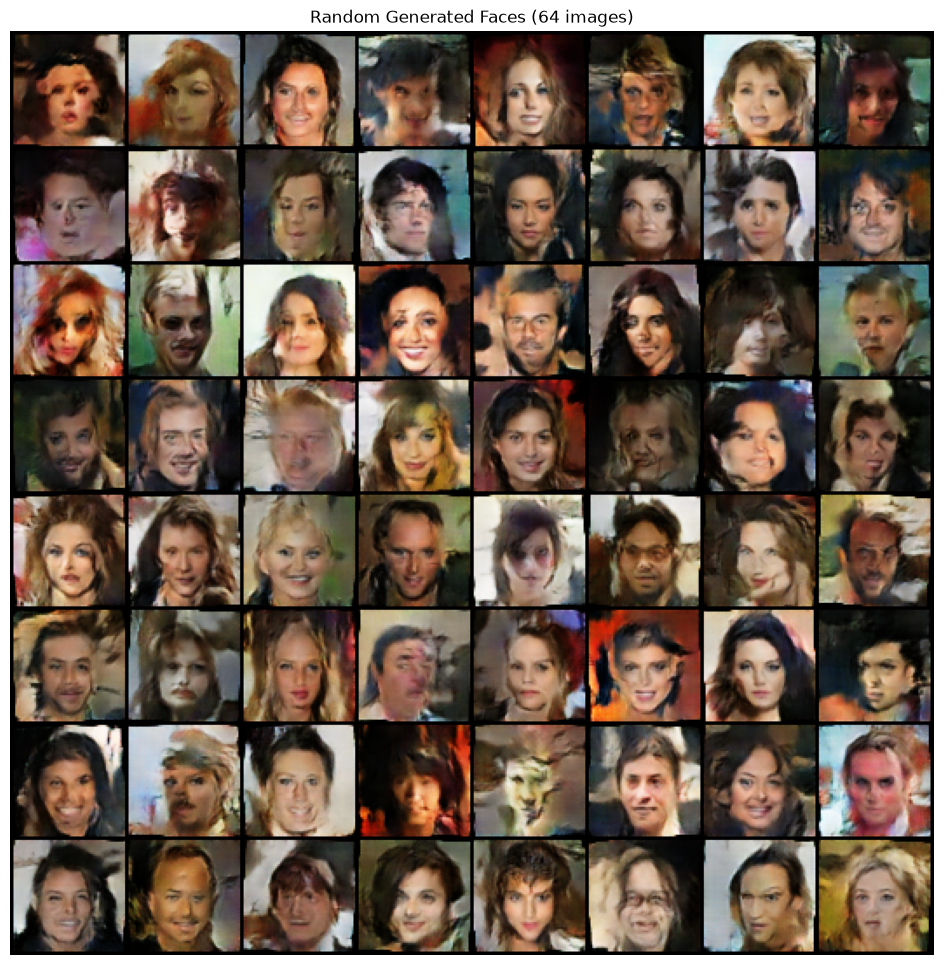

In [ ]:
import torch
import matplotlib.pyplot as plt

def load_models_only(checkpoint_path, encoder, generator, discriminator, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    encoder.load_state_dict(checkpoint['encoder_state'])
    generator.load_state_dict(checkpoint['generator_state'])
    discriminator.load_state_dict(checkpoint['discriminator_state'])
    
    print(f"✅ Модели загружены")
    return encoder, generator, discriminator

encoder = ResnetVitEncoder().to(device)
generator = DecoderGenerator().to(device)
discriminator = Discriminator().to(device)

encoder, generator, discriminator = load_models_only(
    './checkpoints/best.pt',
    encoder, generator, discriminator, device
)

encoder.eval()
generator.eval()
discriminator.eval()


def generate_random_faces(generator, device, n_images=64, latent_dim=128, save_path=None):
    generator.eval()
    
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, device=device)
        fake_images = generator(z)
        fake_images = (fake_images * 0.5 + 0.5).clamp(0, 1)
        
        grid = utils.make_grid(fake_images, nrow=8, normalize=False)
        plt.figure(figsize=(12, 12))
        plt.imshow(grid.permute(1, 2, 0).cpu())
        plt.axis('off')
        plt.title(f'Random Generated Faces ({n_images} images)')
        
        if save_path:
            plt.savefig(save_path, bbox_inches='tight', dpi=150)
            print(f"✅ Изображение сохранено: {save_path}")
        plt.show()
    
    generator.train()
    return fake_images

faces = generate_random_faces(
    generator, device, 
    n_images=64, 
    save_path='generated_faces.png'
)

✅ Изображение сохранено: reconstructions.png


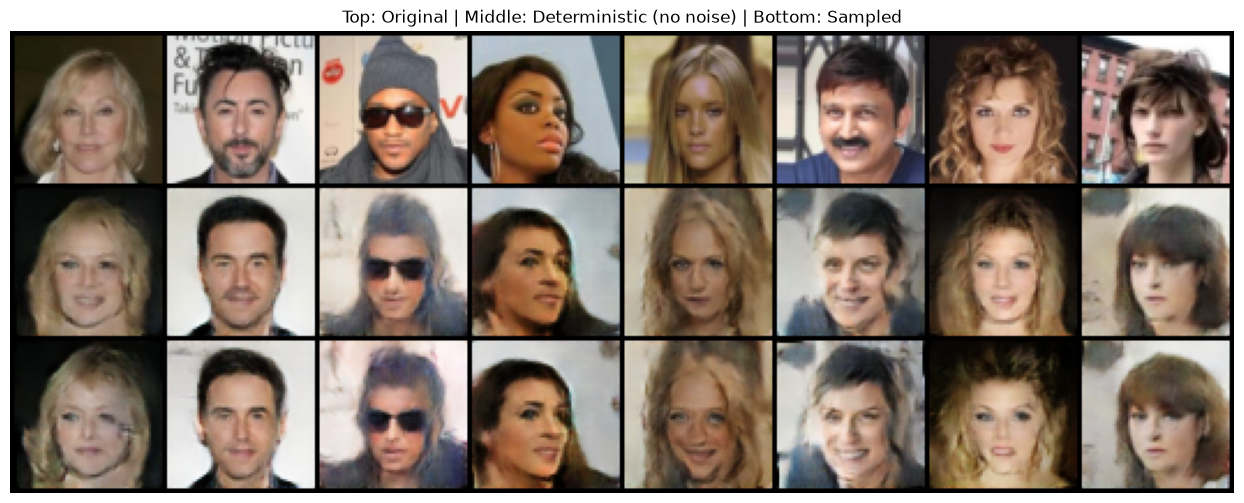

In [ ]:
def reconstruct_specific_images(encoder, generator, val_loader, device, n_images=8, save_path=None):
    encoder.eval()
    generator.eval()
    
    x = next(iter(val_loader))[18: 18 + n_images].to(device)
    
    with torch.no_grad():
        mu, logvar = encoder(x)
        z = reparameterize(mu, logvar)
        x_recon = generator(z)
        
        x_det = generator(mu)
    
    orig = (x * 0.5 + 0.5).clamp(0, 1)
    recon = (x_recon * 0.5 + 0.5).clamp(0, 1)
    det = (x_det * 0.5 + 0.5).clamp(0, 1)
    
    comparison = torch.cat([orig, det, recon], dim=0)
    grid = utils.make_grid(comparison, nrow=n_images)
    
    plt.figure(figsize=(16, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Top: Original | Middle: Deterministic (no noise) | Bottom: Sampled')
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"✅ Изображение сохранено: {save_path}")
    plt.show()
    
    encoder.train()
    generator.train()
    return orig, recon

orig, recon = reconstruct_specific_images(
    encoder, generator, val_loader, device,
    n_images=8, save_path='reconstructions.png'
)